In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## Step 1: Load or Generate Dataset
We'll use `make_blobs` to generate a synthetic dataset for demonstration. You can replace this with your dataset.


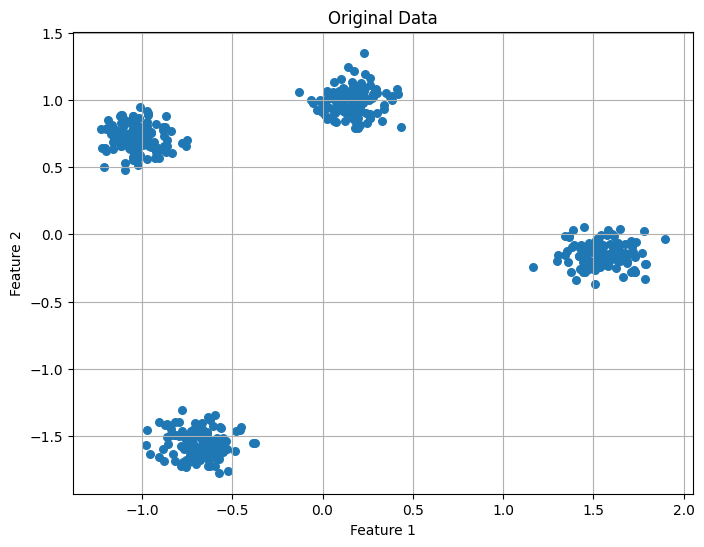

In [32]:
# Generate synthetic dataset
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)


# Standardize data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=30, cmap='viridis')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


## Step 2: Elbow Method to Determine Optimal K
We'll run K-Means for a range of `k` values and calculate the Within-Cluster Sum of Squares (WCSS) to find the "elbow point."


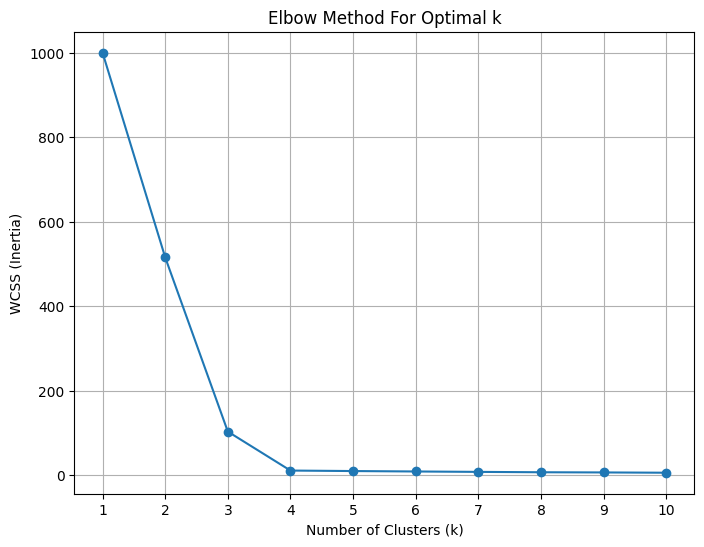

In [33]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center

# Plotting the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


## Step 3: Apply K-Means with Optimal k
From the Elbow plot, choose the k at the "elbow" point. For our synthetic dataset, k=4 seems ideal.


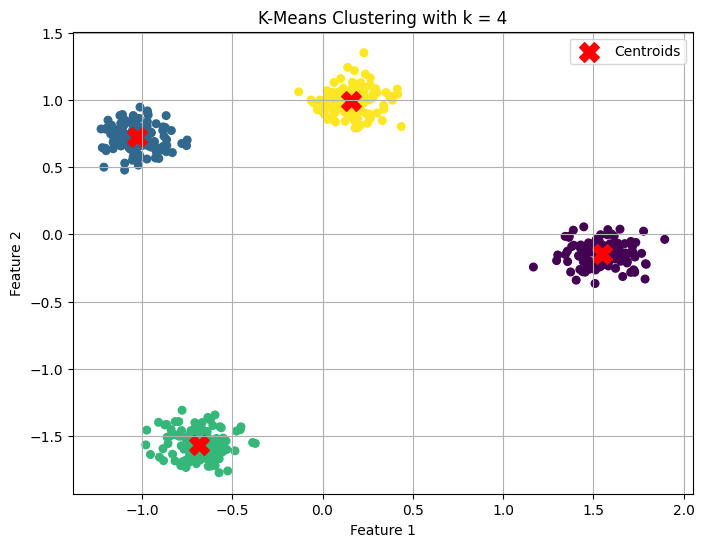

In [34]:
optimal_k = 4  # based on visual inspection of the elbow
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', label='Centroids')
plt.title(f"K-Means Clustering with k = {optimal_k}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


## Conclusion
- We successfully applied K-Means clustering to the dataset.
- The Elbow Method helped us find the optimal number of clusters.
- Visualizations clearly show the clusters and their centroids.
